In [7]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target


In [12]:
df = pd.DataFrame({
    "mean_radius": data.data[:, 0],
    "target": data.target
})


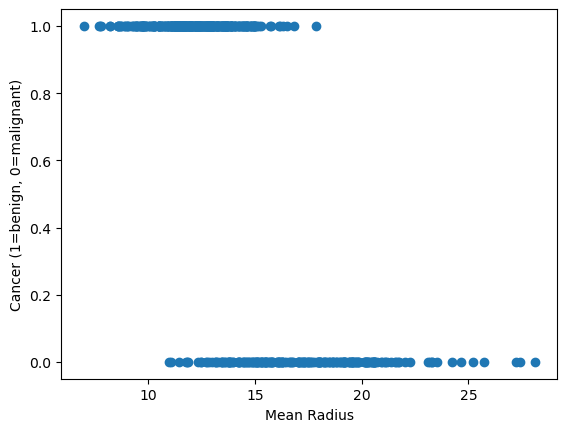

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df["mean_radius"], df["target"])
plt.xlabel("Mean Radius")
plt.ylabel("Cancer (1=benign, 0=malignant)")
plt.show()


In [14]:
from sklearn.linear_model import LogisticRegression

X = df[["mean_radius"]]   # 2D
y = df["target"]          # 1D

model = LogisticRegression()
model.fit(X, y)


LogisticRegression()

In [15]:
w = model.coef_[0][0]
b = model.intercept_[0]
print(w, b)


-1.024756086619869 15.120902004497601


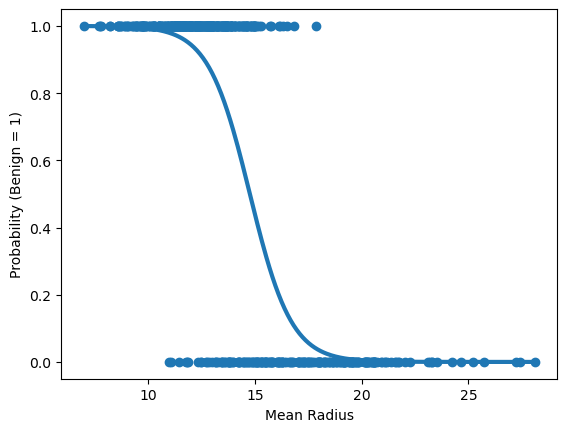

In [16]:
import numpy as np

# generate smooth x-line
x_vals = np.linspace(df.mean_radius.min(), df.mean_radius.max(), 300)
z = w * x_vals + b
y_vals = 1 / (1 + np.exp(-z))

plt.scatter(df["mean_radius"], df["target"])
plt.plot(x_vals, y_vals, linewidth=3)
plt.xlabel("Mean Radius")
plt.ylabel("Probability (Benign = 1)")
plt.show()


In [17]:
model.predict_proba([[15]])


c:\Users\DEEPAK\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.56228462, 0.43771538]])